# 🍕 Pizza Sales — Exploración, ETL y Estadística Descriptiva

Este notebook realiza:
1. **Carga y exploración inicial** de los datos crudos.
2. **ETL**: limpieza, tipado correcto y transformación de columnas.
3. **Análisis exploratorio (EDA)** con estadísticas y visualizaciones.
4. **Cálculos estadísticos básicos** (medidas de tendencia central, dispersión, outliers, etc.).

Archivo fuente: `pizza_sales.csv`


## 1. Imports y configuración

In [29]:
import micropip
await micropip.install("seaborn")

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)


## 2. Carga de datos

El CSV usa `;` como separador de campos, por lo que hay que indicarlo explícitamente en `read_csv`.


In [31]:
RUTA_ARCHIVO = "pizza_sales.csv"  # ajustar la ruta si es necesario

df_raw = pd.read_csv(RUTA_ARCHIVO, sep=";")
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")
df_raw.head()


Filas: 48,620 | Columnas: 18


,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,Day Name,Order Day,Day Number,Month Name,Month,Order Month
0,164,71,thai_ckn_l,1,02/01/2015 00:00,30/12/1899 11:40:50,"20,75","20,75",Large,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza,Friday,FRI,5,January,1,JAN
1,188,79,thai_ckn_l,1,02/01/2015 00:00,30/12/1899 12:29:11,"20,75","20,75",Large,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza,Friday,FRI,5,January,1,JAN
2,191,81,thai_ckn_l,1,02/01/2015 00:00,30/12/1899 12:40:01,"20,75","20,75",Large,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza,Friday,FRI,5,January,1,JAN
3,209,89,thai_ckn_l,1,02/01/2015 00:00,30/12/1899 14:30:19,"20,75","20,75",Large,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza,Friday,FRI,5,January,1,JAN
4,1171,513,thai_ckn_l,1,09/01/2015 00:00,30/12/1899 12:22:48,"20,75","20,75",Large,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza,Friday,FRI,5,January,1,JAN


## 3. Exploración inicial (antes del ETL)

In [32]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   pizza_id           48620 non-null  int64
 1   order_id           48620 non-null  int64
 2   pizza_name_id      48620 non-null  str  
 3   quantity           48620 non-null  int64
 4   order_date         48620 non-null  str  
 5   order_time         48620 non-null  str  
 6   unit_price         48620 non-null  str  
 7   total_price        48620 non-null  str  
 8   pizza_size         48620 non-null  str  
 9   pizza_category     48620 non-null  str  
 10  pizza_ingredients  48620 non-null  str  
 11  pizza_name         48620 non-null  str  
 12  Day Name           48620 non-null  str  
 13  Order Day          48620 non-null  str  
 14  Day Number         48620 non-null  int64
 15  Month Name         48620 non-null  str  
 16  Month              48620 non-null  int64
 17  Order Month        4862

In [33]:
# Valores nulos por columna
df_raw.isna().sum().to_frame("nulos")


,nulos
pizza_id,0
order_id,0
pizza_name_id,0
quantity,0
order_date,0
order_time,0
unit_price,0
total_price,0
pizza_size,0
pizza_category,0


In [34]:
# Duplicados exactos
print(f"Filas duplicadas: {df_raw.duplicated().sum()}")

# Valores únicos por columna categórica clave
for col in ["pizza_size", "pizza_category", "Day Name", "Month Name"]:
    print(f"\n{col}: {df_raw[col].unique()}")


Filas duplicadas: 0

pizza_size: <StringArray>
['Large', 'Medium', 'Small', 'Extra Large', 'XX Large']
Length: 5, dtype: str

pizza_category: <StringArray>
['Chicken', 'Veggie', 'Supreme', 'Classic']
Length: 4, dtype: str

Day Name: <StringArray>
['Friday', 'Wednesday', 'Thursday', 'Saturday', 'Tuesday', 'Monday', 'Sunday']
Length: 7, dtype: str

Month Name: <StringArray>
['January', 'July', 'February', 'November', 'December', 'March', 'August', 'April', 'September', 'May', 'October', 'June']
Length: 12, dtype: str


In [35]:
# Vistazo a columnas problemáticas: precios con coma decimal y fechas
df_raw[["order_date", "order_time", "unit_price", "total_price"]].head()


,order_date,order_time,unit_price,total_price
0,02/01/2015 00:00,30/12/1899 11:40:50,"20,75","20,75"
1,02/01/2015 00:00,30/12/1899 12:29:11,"20,75","20,75"
2,02/01/2015 00:00,30/12/1899 12:40:01,"20,75","20,75"
3,02/01/2015 00:00,30/12/1899 14:30:19,"20,75","20,75"
4,09/01/2015 00:00,30/12/1899 12:22:48,"20,75","20,75"


## 4. ETL (Extract, Transform, Load)

Se detectaron los siguientes problemas a resolver:

- `unit_price` y `total_price` usan **coma como separador decimal** (formato europeo) → hay que convertirlos a `float`.
- `order_date` está en formato `dd/mm/yyyy` → convertir a `datetime`.
- `order_time` viene con una fecha "fantasma" (`30/12/1899`, típico de exportaciones desde Excel) y solo la **hora** es relevante → extraer únicamente el componente de tiempo.
- Columnas categóricas (`pizza_size`, `pizza_category`, `Day Name`, `Month Name`) se pueden tipar como `category` para optimizar memoria.
- Se estandarizan nombres de columnas (snake_case, sin espacios).


In [36]:
df = df_raw.copy()

# --- 4.1 Normalizar nombres de columnas ---
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
df.rename(columns={"order_month": "order_month_abbr"}, inplace=True)
df.columns.tolist()


['pizza_id',
 'order_id',
 'pizza_name_id',
 'quantity',
 'order_date',
 'order_time',
 'unit_price',
 'total_price',
 'pizza_size',
 'pizza_category',
 'pizza_ingredients',
 'pizza_name',
 'day_name',
 'order_day',
 'day_number',
 'month_name',
 'month',
 'order_month_abbr']

In [37]:
# --- 4.2 Corregir precios (coma -> punto decimal) y convertir a float ---
for col in ["unit_price", "total_price"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

df[["unit_price", "total_price"]].describe()


,unit_price,total_price
count,48620.000000,48620.000000
mean,16.494132,16.821474
std,3.621789,4.437398
min,9.750000,9.750000
25%,12.750000,12.750000
50%,16.500000,16.500000
75%,20.250000,20.500000
max,35.950000,83.000000


In [38]:
# --- 4.3 Convertir order_date a datetime ---
df["order_date"] = pd.to_datetime(df["order_date"], format="%d/%m/%Y %H:%M")

# --- 4.4 Extraer solo la hora de order_time (ignorando la fecha "fantasma" de Excel) ---
df["order_time"] = pd.to_datetime(df["order_time"], format="%d/%m/%Y %H:%M:%S").dt.time

# Combinar fecha + hora en un solo timestamp para análisis temporal
df["order_datetime"] = pd.to_datetime(
    df["order_date"].dt.strftime("%Y-%m-%d") + " " + df["order_time"].astype(str)
)

df[["order_date", "order_time", "order_datetime"]].head()


,order_date,order_time,order_datetime
0,2015-01-02,11:40:50,2015-01-02 11:40:50
1,2015-01-02,12:29:11,2015-01-02 12:29:11
2,2015-01-02,12:40:01,2015-01-02 12:40:01
3,2015-01-02,14:30:19,2015-01-02 14:30:19
4,2015-01-09,12:22:48,2015-01-09 12:22:48


In [39]:
# --- 4.5 Tipar columnas categóricas ---
cat_cols = ["pizza_size", "pizza_category", "day_name", "order_day", "month_name", "order_month_abbr"]
for col in cat_cols:
    df[col] = df[col].astype("category")

# Ordenar pizza_size como categoría ordinal (útil para gráficos y agregaciones)
size_order = ["Small", "Medium", "Large", "Extra Large", "XX Large"]
df["pizza_size"] = pd.Categorical(df["pizza_size"], categories=size_order, ordered=True)

df.dtypes


pizza_id                      int64
order_id                      int64
pizza_name_id                   str
quantity                      int64
order_date           datetime64[us]
order_time                   object
unit_price                  float64
total_price                 float64
pizza_size                 category
pizza_category             category
pizza_ingredients               str
pizza_name                      str
day_name                   category
order_day                  category
day_number                    int64
month_name                 category
month                         int64
order_month_abbr           category
order_datetime       datetime64[us]
dtype: object

In [40]:
# --- 4.6 Validaciones post-ETL ---
# Chequear que total_price == unit_price * quantity (dentro de una tolerancia)
inconsistencias = df[~np.isclose(df["unit_price"] * df["quantity"], df["total_price"], atol=0.01)]
print(f"Filas con inconsistencia unit_price*quantity != total_price: {len(inconsistencias)}")

# Chequear duplicados de pizza_id (debería ser único por línea de pedido)
print(f"pizza_id duplicados: {df['pizza_id'].duplicated().sum()}")

# Rango de fechas
print(f"Rango de fechas: {df['order_date'].min().date()} → {df['order_date'].max().date()}")


Filas con inconsistencia unit_price*quantity != total_price: 0
pizza_id duplicados: 0
Rango de fechas: 2015-01-01 → 2015-12-31


In [41]:
# --- 4.7 Dataset limpio final ---
print(f"Shape final: {df.shape}")
df.head()


Shape final: (48620, 19)


,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name,day_name,order_day,day_number,month_name,month,order_month_abbr,order_datetime
0,164,71,thai_ckn_l,1,2015-01-02,11:40:50,20.75,20.75,Large,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza,Friday,FRI,5,January,1,JAN,2015-01-02 11:40:50
1,188,79,thai_ckn_l,1,2015-01-02,12:29:11,20.75,20.75,Large,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza,Friday,FRI,5,January,1,JAN,2015-01-02 12:29:11
2,191,81,thai_ckn_l,1,2015-01-02,12:40:01,20.75,20.75,Large,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza,Friday,FRI,5,January,1,JAN,2015-01-02 12:40:01
3,209,89,thai_ckn_l,1,2015-01-02,14:30:19,20.75,20.75,Large,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza,Friday,FRI,5,January,1,JAN,2015-01-02 14:30:19
4,1171,513,thai_ckn_l,1,2015-01-09,12:22:48,20.75,20.75,Large,Chicken,"Chicken, Pineapple, Tomatoes, Red Peppers, Tha...",The Thai Chicken Pizza,Friday,FRI,5,January,1,JAN,2015-01-09 12:22:48


## 5. Análisis Exploratorio de Datos (EDA)

### 5.1 Estadísticas descriptivas generales

In [42]:
df.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
pizza_id,48620.0,24310.500000,14035.529381,1.00,12155.75,24310.5,36465.25,48620.00
order_id,48620.0,10701.479761,6180.119770,1.00,5337.00,10682.5,16100.00,21350.00
quantity,48620.0,1.019622,0.143077,1.00,1.00,1.0,1.00,4.00
unit_price,48620.0,16.494132,3.621789,9.75,12.75,16.5,20.25,35.95
total_price,48620.0,16.821474,4.437398,9.75,12.75,16.5,20.50,83.00
day_number,48620.0,3.171905,1.976784,0.00,1.00,3.0,5.00,6.00
month,48620.0,6.451131,3.435420,1.00,3.00,6.0,9.00,12.00


In [43]:
df.describe(include="category").T


,count,unique,top,freq
pizza_size,48620,5,Large,18526
pizza_category,48620,4,Classic,14579
day_name,48620,7,Friday,8106
order_day,48620,7,FRI,8106
month_name,48620,12,July,4301
order_month_abbr,48620,12,JUL,4301


### 5.2 Ventas por categoría de pizza

In [44]:
ventas_categoria = (
    df.groupby("pizza_category", observed=True)
    .agg(pedidos=("pizza_id", "count"), unidades=("quantity", "sum"), ingresos=("total_price", "sum"))
    .sort_values("ingresos", ascending=False)
)
ventas_categoria


,pedidos,unidades,ingresos
pizza_category,,,
Classic,14579,14888,220053.10
Supreme,11777,11987,208197.00
Chicken,10815,11050,195919.50
Veggie,11449,11649,193690.45


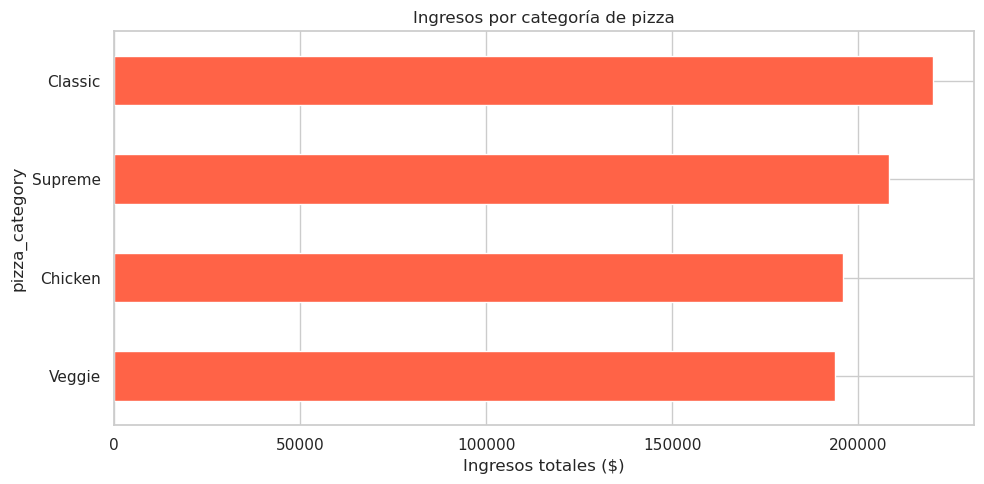

In [45]:
fig, ax = plt.subplots()
ventas_categoria["ingresos"].sort_values().plot(kind="barh", ax=ax, color="tomato")
ax.set_xlabel("Ingresos totales ($)")
ax.set_title("Ingresos por categoría de pizza")
plt.tight_layout()
plt.show()


### 5.3 Ventas por tamaño de pizza

In [46]:
ventas_size = (
    df.groupby("pizza_size", observed=True)
    .agg(unidades=("quantity", "sum"), ingresos=("total_price", "sum"))
)
ventas_size


,unidades,ingresos
pizza_size,,
Small,14403,178076.50
Medium,15635,249382.25
Large,18956,375318.70
Extra Large,552,14076.00
XX Large,28,1006.60


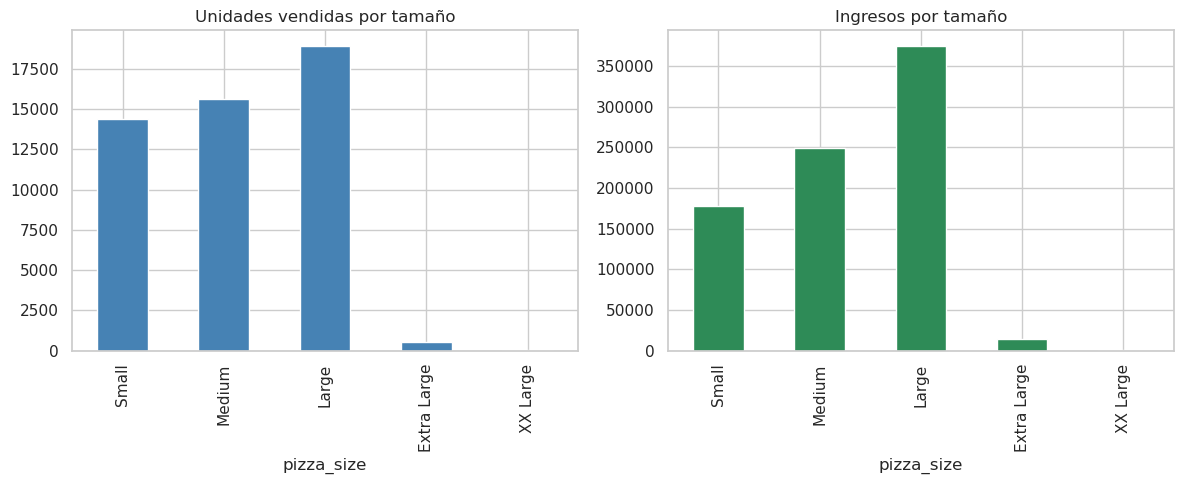

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ventas_size["unidades"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Unidades vendidas por tamaño")
ventas_size["ingresos"].plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("Ingresos por tamaño")
plt.tight_layout()
plt.show()


### 5.4 Top 10 pizzas más vendidas (por unidades)

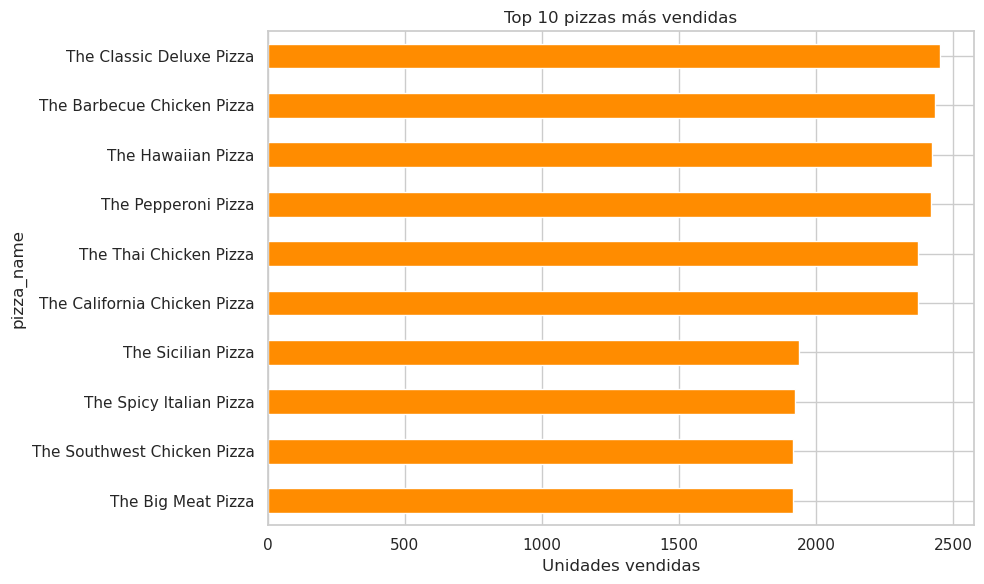

In [48]:
top_pizzas = (
    df.groupby("pizza_name", observed=True)["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
top_pizzas.sort_values().plot(kind="barh", ax=ax, color="darkorange")
ax.set_xlabel("Unidades vendidas")
ax.set_title("Top 10 pizzas más vendidas")
plt.tight_layout()
plt.show()


### 5.5 Estacionalidad: ventas por día de la semana y por mes

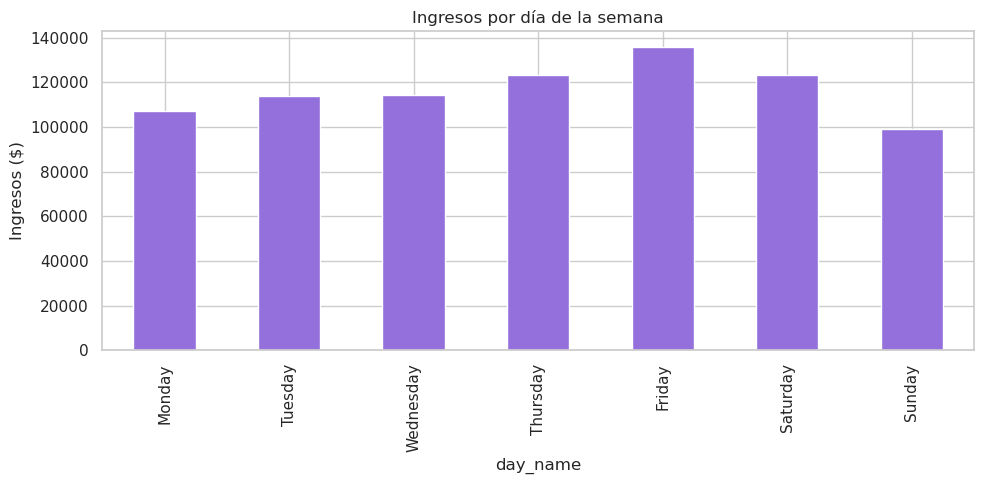

In [49]:
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
ventas_dia = df.groupby("day_name", observed=True)["total_price"].sum().reindex(orden_dias)

fig, ax = plt.subplots()
ventas_dia.plot(kind="bar", ax=ax, color="mediumpurple")
ax.set_ylabel("Ingresos ($)")
ax.set_title("Ingresos por día de la semana")
plt.tight_layout()
plt.show()


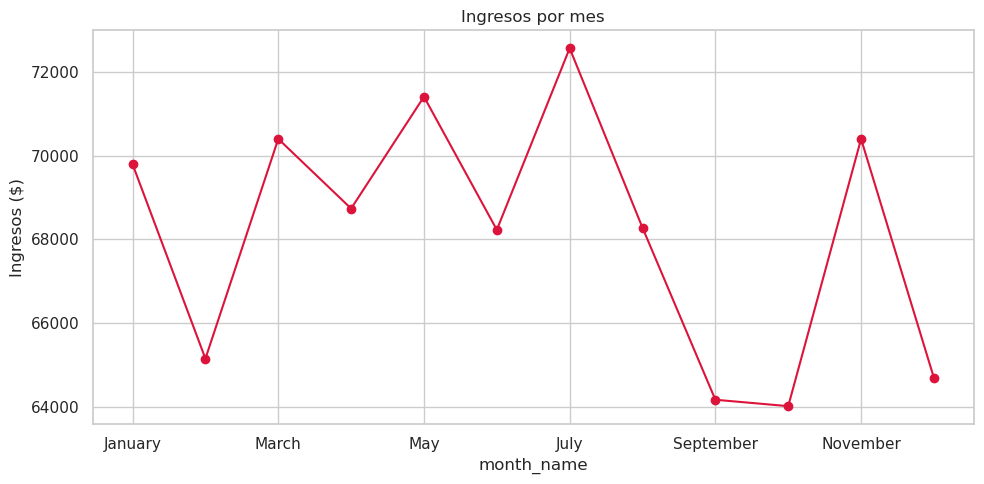

In [50]:
orden_meses = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
ventas_mes = df.groupby("month_name", observed=True)["total_price"].sum().reindex(orden_meses)

fig, ax = plt.subplots()
ventas_mes.plot(kind="line", marker="o", ax=ax, color="crimson")
ax.set_ylabel("Ingresos ($)")
ax.set_title("Ingresos por mes")
plt.tight_layout()
plt.show()


### 5.6 Distribución de precios y cantidades

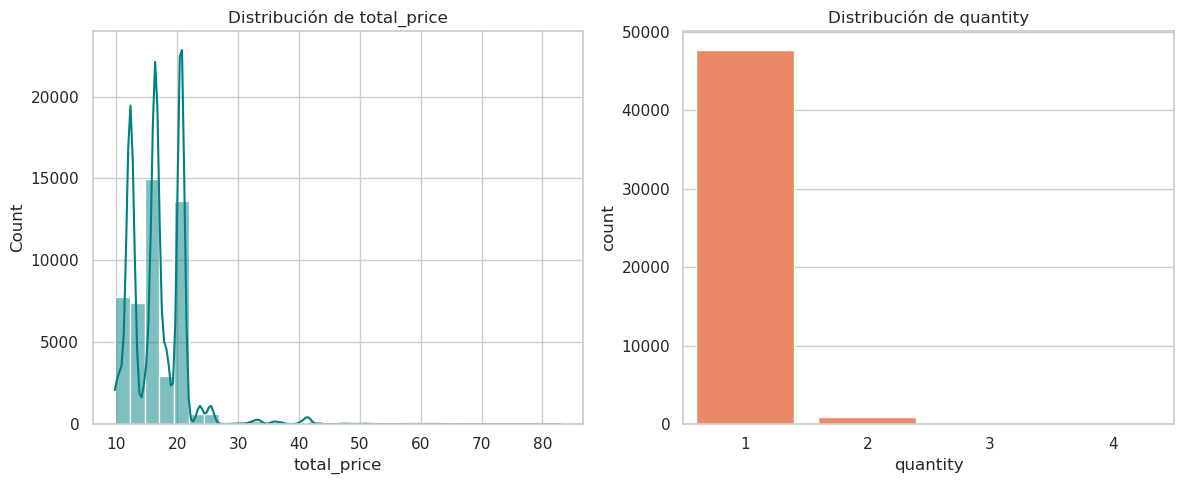

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df["total_price"], bins=30, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribución de total_price")
sns.countplot(x="quantity", data=df, ax=axes[1], color="coral")
axes[1].set_title("Distribución de quantity")
plt.tight_layout()
plt.show()


## 6. Cálculos estadísticos básicos

### 6.1 Medidas de tendencia central y dispersión (total_price)

In [52]:
precio = df["total_price"]

stats = {
    "media": precio.mean(),
    "mediana": precio.median(),
    "moda": precio.mode().iloc[0],
    "desvío_estándar": precio.std(),
    "varianza": precio.var(),
    "mínimo": precio.min(),
    "máximo": precio.max(),
    "rango": precio.max() - precio.min(),
    "percentil_25": precio.quantile(0.25),
    "percentil_75": precio.quantile(0.75),
    "asimetría (skew)": precio.skew(),
    "curtosis": precio.kurt(),
}

pd.Series(stats).to_frame("valor").round(3)


,valor
media,16.821
mediana,16.500
moda,20.750
desvío_estándar,4.437
varianza,19.690
mínimo,9.750
máximo,83.000
rango,73.250
percentil_25,12.750
percentil_75,20.500


### 6.2 Detección de outliers (método IQR)

Límite inferior: 1.12 | Límite superior: 32.12
Cantidad de outliers detectados: 613 (1.26% del total)


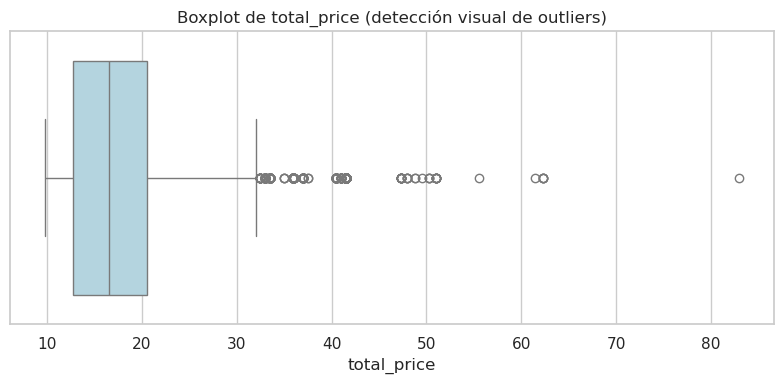

In [53]:
Q1 = precio.quantile(0.25)
Q3 = precio.quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = df[(precio < lim_inf) | (precio > lim_sup)]
print(f"Límite inferior: {lim_inf:.2f} | Límite superior: {lim_sup:.2f}")
print(f"Cantidad de outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% del total)")

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=precio, ax=ax, color="lightblue")
ax.set_title("Boxplot de total_price (detección visual de outliers)")
plt.tight_layout()
plt.show()


### 6.3 Correlación entre variables numéricas

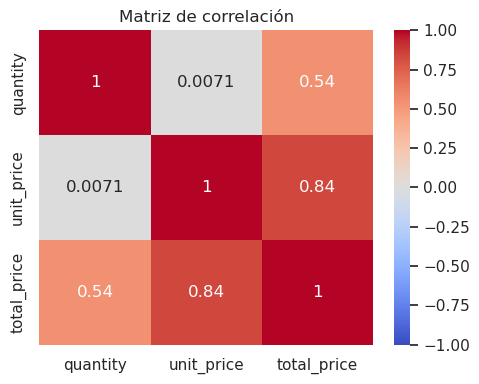

,quantity,unit_price,total_price
quantity,1.000000,0.007142,0.541926
unit_price,0.007142,1.000000,0.836087
total_price,0.541926,0.836087,1.000000


In [54]:
num_cols = ["quantity", "unit_price", "total_price"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

corr


### 6.4 Ticket promedio por pedido (order_id)

Ticket promedio: $38.31
Ticket mediano: $32.50
Ticket máximo: $444.20
Total de pedidos: 21,350


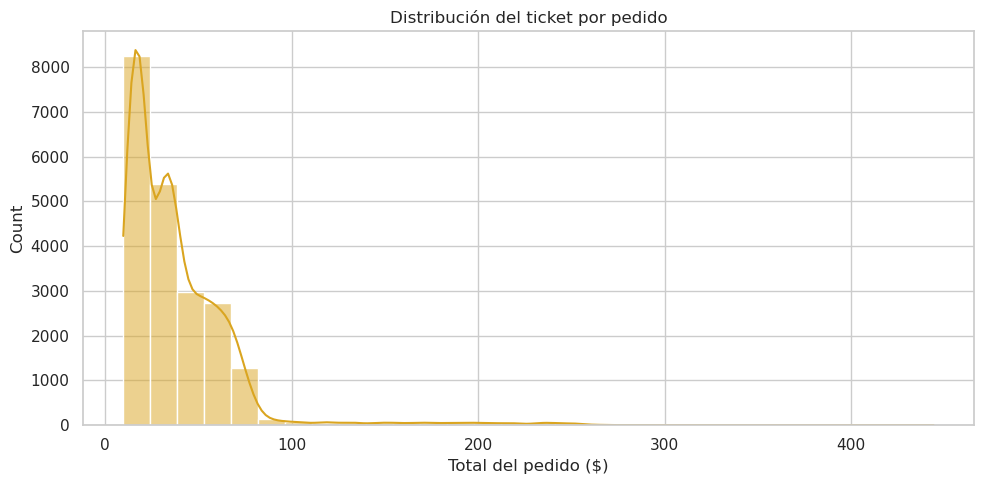

In [55]:
ticket_por_pedido = df.groupby("order_id")["total_price"].sum()

print(f"Ticket promedio: ${ticket_por_pedido.mean():.2f}")
print(f"Ticket mediano: ${ticket_por_pedido.median():.2f}")
print(f"Ticket máximo: ${ticket_por_pedido.max():.2f}")
print(f"Total de pedidos: {ticket_por_pedido.shape[0]:,}")

fig, ax = plt.subplots()
sns.histplot(ticket_por_pedido, bins=30, kde=True, ax=ax, color="goldenrod")
ax.set_title("Distribución del ticket por pedido")
ax.set_xlabel("Total del pedido ($)")
plt.tight_layout()
plt.show()


### 6.5 Análisis por hora del día

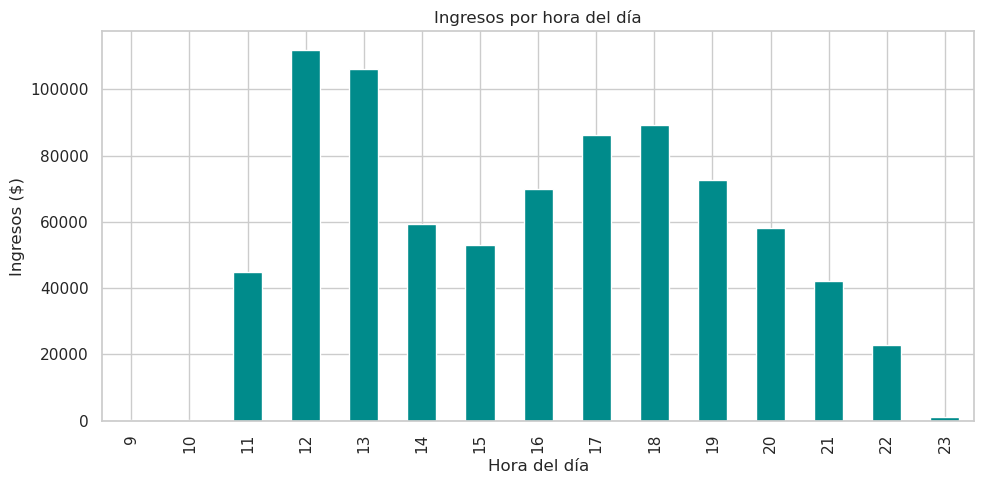

In [56]:
df["hora"] = df["order_datetime"].dt.hour

ventas_hora = df.groupby("hora")["total_price"].sum()

fig, ax = plt.subplots()
ventas_hora.plot(kind="bar", ax=ax, color="darkcyan")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Ingresos ($)")
ax.set_title("Ingresos por hora del día")
plt.tight_layout()
plt.show()


## 7. Resumen ejecutivo

Completar/ajustar con las conclusiones que surjan al ejecutar el notebook, por ejemplo:

- Ingresos totales del período analizado.
- Categoría y tamaño de pizza más rentables.
- Días/horas de mayor demanda.
- Presencia (o no) de outliers relevantes en el ticket promedio.


In [57]:
print(f"Ingresos totales: ${df['total_price'].sum():,.2f}")
print(f"Unidades totales vendidas: {df['quantity'].sum():,}")
print(f"Pedidos totales: {df['order_id'].nunique():,}")
print(f"Ticket promedio: ${ticket_por_pedido.mean():.2f}")
print(f"Categoría más vendida: {ventas_categoria['ingresos'].idxmax()}")
print(f"Tamaño más vendido (unidades): {ventas_size['unidades'].idxmax()}")


Ingresos totales: $817,860.05
Unidades totales vendidas: 49,574
Pedidos totales: 21,350
Ticket promedio: $38.31
Categoría más vendida: Classic
Tamaño más vendido (unidades): Large
